# 05. Đánh giá & trực quan hóa kết quả mô hình K-Means

**Project:** `social-anomaly-clustering`  
**Đề tài:** Ứng dụng kỹ thuật gom nhóm trong phát hiện hành vi bất thường của người dùng mạng xã hội  
**Notebook:** `05_evaluation_visualization.ipynb`

Notebook này tổng hợp và đánh giá kết quả từ thuật toán **K-Means Clustering**.

Mục tiêu là phân tích số lượng người dùng bất thường, tỷ lệ bot trong nhóm bất thường, chất lượng cụm và đưa ra nhận xét cuối cùng cho báo cáo.

> Lưu ý: `bot_label` chỉ được dùng để đánh giá sau khi gom nhóm. Trong quá trình clustering, mô hình không sử dụng nhãn này.


## 1 — Import thư viện và thiết lập đường dẫn

Cell này import các thư viện cần thiết, đồng thời khai báo đường dẫn đến các file kết quả đã tạo ở notebook 03.

Các file đầu vào chính:

```text
results/csv/kmeans_clustered_users.csv
datasets/processed/user_features_scaled.csv
```

Các file đầu ra chính:

```text
results/csv/evaluation_summary.csv
results/csv/algorithm_comparison.csv
results/csv/feature_summary_by_anomaly.csv
results/figures/compare_anomaly_users.png
results/figures/compare_bot_ratio_normal_vs_anomaly.png
results/figures/compare_silhouette_score.png
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RESULT_CSV_DIR = Path("../results/csv")
FIGURE_DIR = Path("../results/figures")
PROCESSED_DIR = Path("../datasets/processed")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)

KMEANS_RESULT_PATH = RESULT_CSV_DIR / "kmeans_clustered_users.csv"
SCALED_FEATURES_PATH = PROCESSED_DIR / "user_features_scaled.csv"

EVALUATION_SUMMARY_PATH = RESULT_CSV_DIR / "evaluation_summary.csv"
ALGORITHM_COMPARISON_PATH = RESULT_CSV_DIR / "algorithm_comparison.csv"
FEATURE_SUMMARY_PATH = RESULT_CSV_DIR / "feature_summary_by_anomaly.csv"

print("K-Means result:", KMEANS_RESULT_PATH)
print("Scaled features:", SCALED_FEATURES_PATH)


K-Means result: ..\results\csv\kmeans_clustered_users.csv
Scaled features: ..\datasets\processed\user_features_scaled.csv


## 2 — Đọc kết quả K-Means

Cell này đọc file kết quả K-Means:

```text
kmeans_clustered_users.csv
```

File này cần có thông tin cụm, nhãn anomaly và nhãn `bot_label` để phục vụ bước đánh giá.


In [2]:
kmeans_result = pd.read_csv(KMEANS_RESULT_PATH)

print("K-Means shape:", kmeans_result.shape)

kmeans_result.head()


K-Means shape: (50000, 14)


,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,cluster,anomaly_score,is_anomaly
0,132131,85,1,2353,0,83,5,0,0,1114,1,1,3.164121,0
1,289683,55,5,9617,1,77,14,2,1,186,0,0,3.057194,0
2,779715,6,2,4363,1,61,10,2,1,296,0,0,1.897890,0
3,696168,54,5,2242,1,49,6,4,1,654,1,0,2.395977,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,2,3.228215,0


**Nhận xét:**  

Dữ liệu kết quả K-Means gồm 50,000 người dùng, chứa đầy đủ nhãn cụm và nhãn bất thường `is_anomaly` được xác định dựa trên top 5% `anomaly_score` cao nhất.


## 3 — Kiểm tra các cột quan trọng

Cell này kiểm tra mỗi file kết quả có đủ các cột cần thiết hay không:

```text
user_id
bot_label
cluster
is_anomaly
```

Nếu thiếu một trong các cột này, các bước đánh giá phía sau có thể bị lỗi.

In [3]:
required_cols = ["user_id", "bot_label", "cluster", "is_anomaly"]

for name, df in [("K-Means", kmeans_result)]:
    print("\n" + name)

    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("All required columns exist.")
        display(df[required_cols].head())



K-Means
All required columns exist.


,user_id,bot_label,cluster,is_anomaly
0,132131,1,1,0
1,289683,0,0,0
2,779715,0,0,0
3,696168,1,0,0
4,704441,1,2,0


**Nhận xét:**  
Nếu output hiển thị `All required columns exist.` thì dữ liệu đã sẵn sàng để đánh giá.  
Cột `cluster` là nhãn cụm do thuật toán tạo ra, còn `is_anomaly` cho biết người dùng có bị đánh dấu bất thường hay không.


## 4 — So sánh số lượng người dùng bất thường

Cell này tạo bảng so sánh số lượng người dùng bất thường được phát hiện bởi mỗi thuật toán.

- K-Means: anomaly là nhóm top 5% có `anomaly_score` cao nhất.


In [4]:
comparison_summary = pd.DataFrame({
    "algorithm": ["K-Means"],
    "total_users": [len(kmeans_result)],
    "anomaly_users": [
        int(kmeans_result["is_anomaly"].sum())
    ]
})

comparison_summary["normal_users"] = (
    comparison_summary["total_users"] - comparison_summary["anomaly_users"]
)

comparison_summary["anomaly_ratio"] = (
    comparison_summary["anomaly_users"] / comparison_summary["total_users"] * 100
).round(2)

comparison_summary


,algorithm,total_users,anomaly_users,normal_users,anomaly_ratio
0,K-Means,50000,2500,47500,5.0


**Nhận xét:**  
Với kết quả hiện tại:

```text
K-Means: 2,500 anomaly users, tương đương 5.00%
```

Mô hình K-Means phát hiện một nhóm nhỏ người dùng có hành vi lệch khỏi phần lớn dữ liệu (khoảng 5%).


## 5 — Biểu đồ số lượng anomaly theo thuật toán

Cell này vẽ biểu đồ cột số lượng người dùng bất thường do K-Means phát hiện.

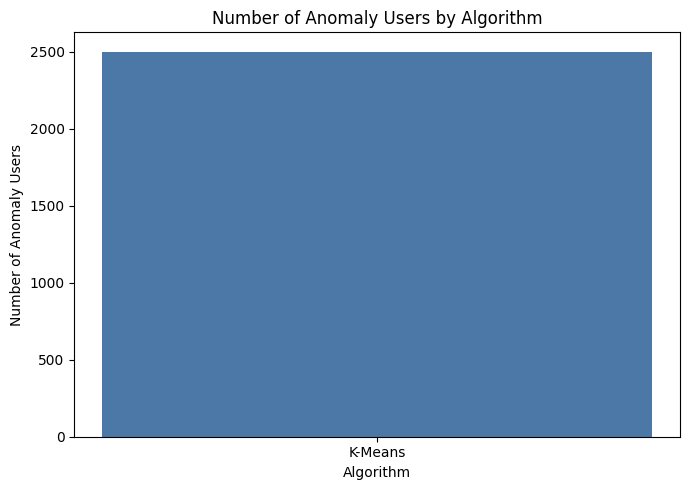

In [5]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_summary["algorithm"], comparison_summary["anomaly_users"], color="#4C78A8")
plt.title("Number of Anomaly Users by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Number of Anomaly Users")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_anomaly_users.png", dpi=300)
plt.show()


**Nhận xét:**  
Biểu đồ cột biểu diễn số lượng người dùng bất thường được phát hiện bởi thuật toán K-Means (2,500 người dùng bất thường đại diện cho top 5% khoảng cách lớn nhất tới tâm cụm).


## 6 — Đánh giá tỷ lệ bot trong nhóm Normal và Anomaly

Cell này sử dụng `bot_label` để kiểm tra xem nhóm anomaly có chứa nhiều bot hơn nhóm normal hay không.

Đây là bước đánh giá sau clustering, không phải huấn luyện có giám sát.

In [6]:
def get_anomaly_evaluation(df, algorithm_name):
    normal_df = df[df["is_anomaly"] == 0]
    anomaly_df = df[df["is_anomaly"] == 1]

    result = {
        "algorithm": algorithm_name,
        "normal_users": len(normal_df),
        "anomaly_users": len(anomaly_df),
        "normal_bot_ratio": normal_df["bot_label"].mean() * 100 if len(normal_df) > 0 else np.nan,
        "anomaly_bot_ratio": anomaly_df["bot_label"].mean() * 100 if len(anomaly_df) > 0 else np.nan,
    }

    result["bot_ratio_diff"] = result["anomaly_bot_ratio"] - result["normal_bot_ratio"]

    return result

evaluation_summary = pd.DataFrame([
    get_anomaly_evaluation(kmeans_result, "K-Means")
]).round(2)

evaluation_summary


,algorithm,normal_users,anomaly_users,normal_bot_ratio,anomaly_bot_ratio,bot_ratio_diff
0,K-Means,47500,2500,49.95,51.64,1.69


**Nhận xét:**  
Kết quả hiện tại:

```text
K-Means:
Normal bot ratio  = 49.95%
Anomaly bot ratio = 51.64%
Chênh lệch        = +1.69%
```

Nhóm anomaly của K-Means có tỷ lệ bot cao hơn nhóm normal một chút. Mức chênh lệch này (+1.69%) cho thấy các đặc trưng hành vi cơ bản hiện tại chưa đủ mạnh để tách biệt hoàn toàn bot và human trong bài toán không giám sát.


## 7 — Biểu đồ tỷ lệ bot: Normal vs Anomaly

Cell này trực quan hóa tỷ lệ bot giữa nhóm normal và anomaly của từng thuật toán.

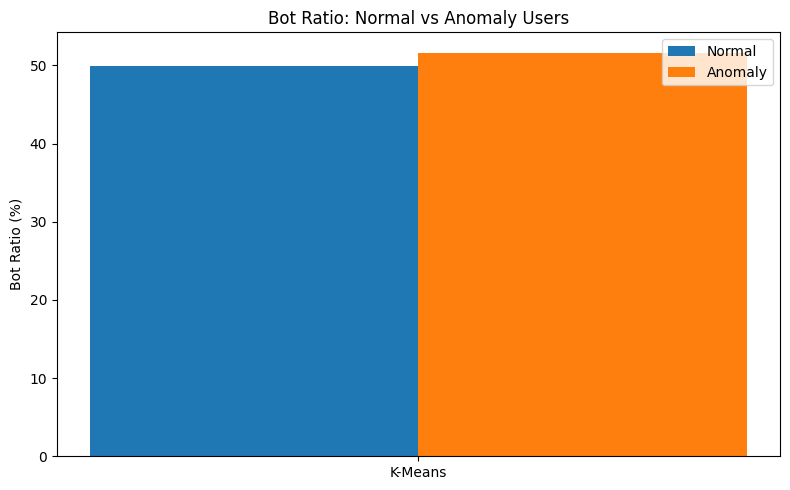

In [7]:
x = np.arange(len(evaluation_summary["algorithm"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    evaluation_summary["normal_bot_ratio"],
    width,
    label="Normal"
)
plt.bar(
    x + width / 2,
    evaluation_summary["anomaly_bot_ratio"],
    width,
    label="Anomaly"
)

plt.xticks(x, evaluation_summary["algorithm"])
plt.ylabel("Bot Ratio (%)")
plt.title("Bot Ratio: Normal vs Anomaly Users")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_bot_ratio_normal_vs_anomaly.png", dpi=300)
plt.show()

**Nhận xét:**  
Biểu đồ cho thấy nhóm anomaly của K-Means có tỷ lệ bot cao hơn nhóm normal một chút. Điều này phù hợp với bản chất bài toán không giám sát: mô hình phát hiện hành vi lệch cụm, không trực tiếp học để phân loại bot/human.


## 8 — So sánh đặc trưng trung bình giữa Normal và Anomaly

Cell này phân tích nhóm anomaly khác nhóm normal ở các đặc trưng nào.

Các feature được so sánh gồm:

```text
retweet_count
mention_count
follower_count
verified
tweet_length
username_length
hashtag_count
has_hashtag
account_age_days
```

In [8]:
feature_cols = [
    "retweet_count",
    "mention_count",
    "follower_count",
    "verified",
    "tweet_length",
    "username_length",
    "hashtag_count",
    "has_hashtag",
    "account_age_days"
]

def summarize_features_by_anomaly(df, algorithm_name):
    available_features = [col for col in feature_cols if col in df.columns]
    summary = df.groupby("is_anomaly")[available_features].mean().reset_index()
    summary.insert(0, "algorithm", algorithm_name)
    return summary

kmeans_feature_summary = summarize_features_by_anomaly(kmeans_result, "K-Means")

feature_summary = kmeans_feature_summary.copy()

feature_summary = feature_summary.round(2)
feature_summary


,algorithm,is_anomaly,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days
0,K-Means,0,49.94,2.51,4990.60,0.5,62.43,9.69,2.50,0.83,624.12
1,K-Means,1,51.20,2.53,4950.64,0.5,66.30,11.92,2.45,0.82,613.19


**Nhận xét:**  

Với kết quả hiện tại:

**K-Means anomaly** có xu hướng:

```text
tweet_length cao hơn normal
username_length cao hơn normal
retweet_count nhỉnh hơn normal
```

Điều này cho thấy K-Means đang đánh dấu những tài khoản có mẫu nội dung/tên tài khoản lệch hơn so với cụm chính.


## 9 — Lưu bảng feature summary

Cell này lưu bảng so sánh đặc trưng giữa normal và anomaly để dùng trong báo cáo.

In [9]:
feature_summary.to_csv(FEATURE_SUMMARY_PATH, index=False)

print("Saved feature summary to:", FEATURE_SUMMARY_PATH)

Saved feature summary to: ..\results\csv\feature_summary_by_anomaly.csv


**Nhận xét:**  
File `feature_summary_by_anomaly.csv` giúp bạn trích số liệu nhanh khi viết báo cáo hoặc làm slide. Đây là bảng rất hữu ích để giải thích “vì sao nhóm anomaly khác nhóm normal”.

## 10 — So sánh số cụm và số anomaly/noise

Cell này tổng hợp:

- K-Means tạo ra bao nhiêu cụm.
- Thuật toán phát hiện bao nhiêu anomaly.


In [10]:
def get_cluster_info(df, algorithm_name):
    clusters = sorted(df["cluster"].unique())

    n_clusters = len(clusters)
    n_noise = int(df["is_anomaly"].sum())

    return {
        "algorithm": algorithm_name,
        "n_clusters": n_clusters,
        "anomaly_or_noise_users": n_noise,
        "anomaly_or_noise_ratio": n_noise / len(df) * 100
    }

cluster_info = pd.DataFrame([
    get_cluster_info(kmeans_result, "K-Means")
]).round(2)

cluster_info


,algorithm,n_clusters,anomaly_or_noise_users,anomaly_or_noise_ratio
0,K-Means,3,2500,5.0


**Nhận xét:**  
Kết quả hiện tại:

```text
K-Means: 3 cụm, 2,500 anomaly users, tỷ lệ 5.00%
```

Mô hình gom nhóm K-Means gom dữ liệu thành 3 cụm dựa trên các đặc trưng hành vi đã chuẩn hóa.


## 11 — Tính Silhouette Score

Cell này tính Silhouette Score cho kết quả cụm của K-Means.

Silhouette Score càng cao thì cụm càng tách biệt tốt. Tuy nhiên, với dữ liệu hành vi mạng xã hội, các cụm thường có sự chồng lấn nên điểm số có thể không cao.


In [11]:
df_scaled = pd.read_csv(SCALED_FEATURES_PATH)

def safe_silhouette_score(X, labels, algorithm_name):
    unique_labels = set(labels)
    if len(unique_labels) < 2:
        return np.nan
    return silhouette_score(X, labels)

kmeans_silhouette = safe_silhouette_score(
    df_scaled,
    kmeans_result["cluster"],
    "K-Means"
)

silhouette_comparison = pd.DataFrame({
    "algorithm": ["K-Means"],
    "silhouette_score": [kmeans_silhouette]
}).round(6)

silhouette_comparison


,algorithm,silhouette_score
0,K-Means,0.151312


**Nhận xét:**  
Kết quả hiện tại:

```text
K-Means silhouette = 0.151312
```

K-Means đạt Silhouette Score là 0.151. Điểm số này tương đối thấp, thể hiện các cụm hành vi có sự chồng lấn nhiều, không hoàn toàn tách biệt rõ ràng.


## 12 — Biểu đồ so sánh Silhouette Score

Cell này vẽ biểu đồ biểu diễn chất lượng cụm của K-Means.


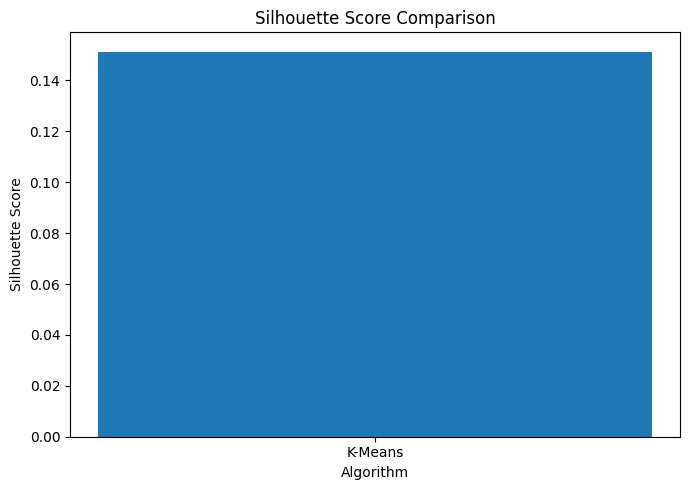

In [12]:
plt.figure(figsize=(7, 5))
plt.bar(silhouette_comparison["algorithm"], silhouette_comparison["silhouette_score"])
plt.title("Silhouette Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_silhouette_score.png", dpi=300)
plt.show()

**Nhận xét:**  
Biểu đồ biểu diễn Silhouette Score của K-Means trên tập dữ liệu.


## 14 — Bảng tổng hợp cuối cùng

Cell này tạo bảng tổng hợp gọn, tránh lỗi merge sinh ra các cột trùng như:

```text
anomaly_users_x
anomaly_users_y
normal_users_x
normal_users_y
```

In [13]:
final_summary = pd.DataFrame({
    "algorithm": comparison_summary["algorithm"],
    "total_users": comparison_summary["total_users"],
    "n_clusters": cluster_info["n_clusters"],
    "anomaly_users": comparison_summary["anomaly_users"],
    "anomaly_ratio": comparison_summary["anomaly_ratio"],
    "normal_bot_ratio": evaluation_summary["normal_bot_ratio"],
    "anomaly_bot_ratio": evaluation_summary["anomaly_bot_ratio"],
    "bot_ratio_diff": evaluation_summary["bot_ratio_diff"],
    "silhouette_score": silhouette_comparison["silhouette_score"]
})

final_summary = final_summary.round(3)
final_summary


,algorithm,total_users,n_clusters,anomaly_users,anomaly_ratio,normal_bot_ratio,anomaly_bot_ratio,bot_ratio_diff,silhouette_score
0,K-Means,50000,3,2500,5.0,49.95,51.64,1.69,0.151


**Nhận xét:**  
Bảng tổng hợp cuối cùng cho thấy:

```text
K-Means:
- 3 cụm
- 2,500 anomaly users
- anomaly ratio 5.00%
- anomaly bot ratio 51.64%
- silhouette score 0.151
```


## 15 — Lưu các bảng đánh giá cuối cùng

Cell này lưu các bảng phục vụ báo cáo.

In [14]:
final_summary.to_csv(EVALUATION_SUMMARY_PATH, index=False)
comparison_summary.to_csv(ALGORITHM_COMPARISON_PATH, index=False)

print("Saved evaluation summary to:", EVALUATION_SUMMARY_PATH)
print("Saved algorithm comparison to:", ALGORITHM_COMPARISON_PATH)

Saved evaluation summary to: ..\results\csv\evaluation_summary.csv
Saved algorithm comparison to: ..\results\csv\algorithm_comparison.csv


## 16 — Nhận xét tổng hợp cho báo cáo

```text
Kết quả thực nghiệm cho thấy K-Means gom nhóm hành vi người dùng thành 3 cụm khác nhau và phát hiện ra 2,500 người dùng bất thường, tương đương 5.00% tổng dữ liệu (đại diện cho những điểm ở xa tâm cụm nhất).

K-Means đạt Silhouette Score là 0.151. Điểm số này cho thấy ranh giới giữa các cụm hành vi không quá rõ nét. Ngoài ra, nhóm anomaly phát hiện bởi K-Means có tỷ lệ bot là 51.64%, nhỉnh hơn nhóm normal (49.95%) khoảng 1.69%.

Nhìn chung, việc gom cụm cơ bản bằng K-Means đóng vai trò quan trọng trong việc thiết lập một baseline trực quan và đơn giản trước khi áp dụng các kỹ thuật trích xuất đặc trưng đồ thị và mô hình Isolation Forest ở các bước nâng cấp sau.
```


## 17 — Kết luận cuối cùng

Qua toàn bộ pipeline baseline, project đã hoàn thành các bước:

1. Khám phá dữ liệu ban đầu.
2. Tiền xử lý dữ liệu và tạo đặc trưng hành vi.
3. Chuẩn hóa dữ liệu hành vi.
4. Áp dụng K-Means để gom nhóm và tính anomaly score baseline.
5. Đánh giá, trực quan hóa và lưu các bảng kết quả phục vụ báo cáo.

Các file đầu ra quan trọng của notebook này:

```text
results/csv/evaluation_summary.csv
results/csv/algorithm_comparison.csv
results/csv/feature_summary_by_anomaly.csv
results/figures/compare_anomaly_users.png
results/figures/compare_bot_ratio_normal_vs_anomaly.png
results/figures/compare_silhouette_score.png
```
